# 15 The op-amp over board temperature

Notebook 14 wants to use the winding's own resistance as a thermometer. Copper gets about 0.39% more
resistive per degree C, so a 5 C thermometer needs R good to about 2%, from room to as hot as the
board gets. R is volts over amps, and the amps come through the shunt and the MCU's on-chip
op-amp. If the op-amp's gain moves with the board's temperature, the thermometer moves with it.

Earlier burst runs on rev 2A board #1 said it does move, by a percent or more between room and
59 C, and in different directions depending on the op-amp's speed mode. Those runs had no
outside truth for the current, so I could not tell the op-amp from the load or the fit. This time
I soldered a pair of sense wires to the shunt pads, put a meter on them, and ran the same set of
measurements at four board temperatures in both op-amp modes.

The questions were:

1. How much does the op-amp's gain move from room to 59 C, in each mode, against the meter?
2. Is it a gain change, an offset, or both?
3. How much of the R drift the bursts saw is the op-amp, and how much is the load?
4. Does the lowest usable duty move with temperature?

If you just want the answer, here it is:

- **In normal mode (high-speed off) the gain moves -0.26% from 28 to 60 C.** On copper that reads
  as 0.66 C of thermometer error, well inside the 5 C budget. The torque-off zero moves 8 counts.
  Back at room the gain is within 0.09% of where it started.
- **In high-speed mode the gain moves +4.3% and the zero 190 counts**, which is 11 C of thermometer
  error at 59 C. It comes back at room.
- **Both modes carry an offset that only shows while the bridge drives**, about +10 counts in
  normal mode. It is why the gain at each level falls a little as the current rises. It does not
  move with temperature in normal mode.
- **The grid itself moved +0.7% and back to -0.4%** over the sweep, in both modes alike. Most of the
  "+1% at 59 C" the earlier normal-mode bursts saw was the load, not the op-amp.
- **The lowest usable duty is 15% (1%) and 10% (3%) in both modes at every temperature.** That
  limit is tap B's sample landing after the drive window closes, a timing fact that does not move
  with temperature, not the op-amp.
- **Decision.** Normal mode on today's hardware. No pull-ups, no gain or shunt rework. The planned
  common-mode test with two pull-ups was dropped, since the normal mode's drift is already inside
  the budget.

## Picking a rig

One dataset, `grid-3r7__dev-v006-2A__dps__opa-temp`. The ladders carry the usual `sense` block, so
the board is read off the data, and every ladder is checked against it as it loads. The "servo" is
the 3.7 ohm resistor grid on J4.

The cell also checks the current floor every ladder ran with against the board entry. The meta.json
says `window_floor_q15` 1734, which is 64 TIM1 ticks, the floor the firmware ships for rev 2A.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

import oscnb
from oscnb import datasets, opasweep as ow
from oscnb.thermal import ALPHA_CU

DS = datasets.load("grid-3r7__dev-v006-2A__dps__opa-temp")
board = DS.board                             # read off the ladders' own sense blocks
rig = oscnb.Rig(board, DS.servo).show()

PLATS = ["room", "43", "59", "room2"]        # the order the plateaus ran
MODES = {"off": "high-speed off (normal)", "on": "high-speed on"}
COL = {"room": "tab:blue", "43": "tab:orange", "59": "tab:red", "room2": "tab:purple"}
P = {(p.plateau, p.hs): p for p in ow.Plateau.all(DS)}
THERM_BUDGET_C = 5.0                         # the winding thermometer's target

# Every ladder is read through DS.read, which checks its meta.json sense block against the board.
# Its window_floor_q15 is the current floor the flashed build ran, as a duty. Turn it back into
# TIM1 ticks with the firmware's own rounding and hold it against the board entry.
q15 = {k: p.meta["drive"]["window_floor_q15"] for k, p in P.items()}
floor_ticks = {k: round((v * board.pwm_half_ticks + (1 << 14)) / (1 << 15)) for k, v in q15.items()}
print(f"ladder window_floor_q15 {sorted(set(q15.values()))} = {sorted(set(floor_ticks.values()))} ticks; "
      f"board entry floor_i_ticks {board.floor_i_ticks}")
assert set(floor_ticks.values()) == {board.floor_i_ticks}

rows = []
for (pl, hs), p in sorted(P.items(), key=lambda kv: kv[1].capture):
    r = p.regs()
    st, en = r[r.label == "start"], r[r.label == "end"]
    rows.append({"capture": p.capture, "plateau": pl, "op-amp": MODES[hs],
                 "board C, start": st.board_c.mean(), "board C, end": en.board_c.mean(),
                 "zero start": st.current_bias_counts.mean(), "zero end": en.current_bias_counts.mean(),
                 "supply idle mA": st.psu_i_a.mean() * 1e3})
SETUP = pd.DataFrame(rows).set_index("capture")
display(SETUP.round(2))

static load, 4x4 grid of 3.3 ohm on osc-dev-v006 rev 2A, board #1

  board: Rs1 60 mOhm; bare OPA with Rf 6k4 / Rg 430 (G 14.884), Cc 22 pF, Co1 DNP. Terminal taps Rv1/Rv3 6k4 over Rv2/Rv4 1k6 with Cv1/Cv2 100 pF, bottoms and caps returned to VB from Rb1 430 / Rb2 100 (773 counts nominal, about 81 ohm source, so VB rises with the leg current under drive). VSNS 6k4/1k6 to GND, unbiased, Cv3 100 pF. A 2A capture's sense block differs from board D's in gain_milli and both divider legs. Nothing in the block carries the bias or VSNS parts, or which 2A unit took the capture, so every 2A board shares this entry. Board #1 had Rv3 open for the grid-3r7 2S session: in that dataset tap B reads the VB node instead of terminal B, so only tap A, the rail and the current are graded there. Rv3 is repaired, and a dataset captured with it fitted reads both taps. FLOORS: the 2A build ships 64 ticks for the current and 160 for the terminals (osc-dev-v006 main.rs i_window_min_ticks / v_window_min_ticks). A

value
where            quantity                                           unit                        
board            converter step                                     mV per count          0.8057
                 terminal divider ratio r                                                 5.0000
                 terminal difference                                mV per count          4.0283
                 terminal bias VB                                   mV                  622.6415
                                                                    counts              772.8302
                 driven-low terminal reads                          counts              618.2642
                 motor current                                      mA per count          0.9022
                                                                    counts per A       1108.4521
                 shunt                                              mOhm                 60.0000
                 amplifier gain                                     x                    14.8840
                 rail tap ratio                                                           5.0000
                 sample rate                                        samples per ms       20.0000
                 current settled from (UNVERIFIED)                  % duty                5.3333
                 voltage settled from (UNVERIFIED)                  % duty               13.3333
servo            pot intercept                                      counts                0.0000
                 pot slope                                          counts per degree     1.0000
                 envelope low                                       counts (0 deg)        0.0000
                 envelope high                                      counts (0 deg)        0.0000
                 runway                                             counts                0.0000
                 seek guard low                                     counts                0.0000
                 seek guard high                                    counts                0.0000
servo (measured) r_load [3.6, 3.8] DMM 200 ohm range at the grid... Ohm                   3.7000

ladder window_floor_q15 [1734] = [64] ticks; board entry floor_i_ticks 64


,plateau,op-amp,"board C, start","board C, end",zero start,zero end,supply idle mA
capture,,,,,,,
capture-1,room,high-speed off (normal),28.06,29.28,1178.33,1187.03,13.49
capture-2,room,high-speed on,29.04,29.57,1105.93,1111.93,13.80
capture-3,43,high-speed on,43.74,44.31,1052.43,1058.63,13.74
capture-4,43,high-speed off (normal),44.11,44.13,1174.00,1181.17,13.25
capture-5,59,high-speed off (normal),60.03,60.64,1170.47,1178.83,13.32
capture-6,59,high-speed on,60.37,60.71,916.13,919.93,13.76
capture-7,room2,high-speed off (normal),29.67,30.60,1177.67,1185.87,13.30
capture-8,room2,high-speed on,30.41,30.11,1101.93,1111.93,13.74


## 1. The setup

The board sat in a filament dryer with JP2 on IN, so the board NTC reads the board itself. Everything
else stayed outside at room. That is the grid on J4, the LinkE, the osc adapter, and a DPS-150
bench supply on the battery wires in place of the LiPo. A B41T+ meter read DC volts across Rs1, the 60 mOhm
shunt, on a twisted pair soldered to the inner edges of its pads. That is exactly the voltage the
op-amp sees, so it is the op-amp's input truth, and the shunt's own resistance drops out of the
test.

At each plateau (room, 43 C, 59 C, then back to room) the driver script
(`captures/bench/c0.py` in the bringup repo) did this once per op-amp mode, flashing the mode's
image in place over SWD each time:

1. Torque off, 30 snapshots of the zero, both taps and the board NTC.
2. **DC levels.** 100% duty so the current is steady DC, the supply at 4.5, 5.5, 7.2 and 8.0 V,
   about 5 s each. The chip's current, both taps, the meter and the supply's readback.
3. **Duty ladder.** `osc sweep --static-load` from 3% to 40% at 7.9 V.
4. **Bursts.** Ten `osc ident burst --static-load` runs, alternating one tap and both taps.
5. Torque off, 30 more snapshots.

The experiment in short:

- **Model.** The chip's current over its torque-off zero is $n = b + G v$ counts, with $v$ the meter's
  volts across Rs1, $G$ the gain in counts per volt and $b$ any offset the drive adds.
- **Estimator.** $G_0 = \sum n v / \sum v^2$, the gain through zero, which is what the firmware's
  fixed counts/A sees. And the free line's slope and intercept, which split the gain from the
  offset.
- **Validity envelope.** 54 to 99 mV across the shunt (0.9 to 1.65 A), board 28 to 61 C, DC at 100%
  duty.
- **Accuracy.** Graded against the meter. Gain drift is a ratio of two readings on the same meter
  range, so the meter's own scale cancels. The meter stayed at room.

### What counts as the truth

Three things said how much current flowed at each level. The meter over the nominal shunt, the
supply's own readback less the board's idle draw, and the chip. Then I moved the meter to J4 once,
at room, to check the terminal chain against the grid itself.

In [2]:
# Three ways to say how much current flowed at each DC level:
#   i_meter  the meter's volts across Rs1 over the nominal 60 mOhm (the op-amp's input truth)
#   i_psu    the DPS-150's own readback, less the board's idle draw before the run
#   chip     the op-amp and ADC, current counts over the torque-off zero at the nominal counts/A
DC = pd.concat([p.dc().assign(plateau=pl, hs=hs) for (pl, hs), p in P.items()], ignore_index=True)
DC["i_chip"] = DC.i_net_mean * board.a_per_count
DC["psu_over_meter"] = DC.i_psu / DC.i_meter
DC["chip_over_meter"] = DC.i_chip / DC.i_meter
print(f"supply readback / meter: {DC.psu_over_meter.mean():.4f} "
      f"(range {DC.psu_over_meter.min():.4f} .. {DC.psu_over_meter.max():.4f}, {len(DC)} levels)")
print(f"chip / meter:            {DC.chip_over_meter.mean():.4f} "
      f"(range {DC.chip_over_meter.min():.4f} .. {DC.chip_over_meter.max():.4f})")

# How clean is each level? The meter's spread over its steady samples, and whether the chip
# ever touched full scale.
chk = []
for (pl, hs), p in P.items():
    for v in p.dc()["dir"]:
        s = p.samples(v)
        me = s[(s.src == "meter") & (s.steady == 1)].meter_v.abs()
        ch = s[(s.src == "chip") & (s.steady == 1)]
        chk.append({"meter samples": len(me), "meter sd %": me.std() / me.mean() * 100,
                    "chip samples": len(ch), "chip at full scale": int((ch.current >= 4095).sum())})
chk = pd.DataFrame(chk)
print(f"per level: {chk['meter samples'].min()}..{chk['meter samples'].max()} steady meter samples, "
      f"meter sd up to {chk['meter sd %'].max():.2f}%, {chk['chip samples'].min()}..{chk['chip samples'].max()} "
      f"chip samples, {chk['chip at full scale'].sum()} at full scale")

# The voltage chain against the grid itself: meter on J4, the same 100% duty levels.
J4 = pd.read_csv(DS.path / "j4" / "capture-1" / "dc.csv")
J4["v_j4"] = J4.meter_v.abs()
J4["v_ab_chip"] = (J4.vmotor_a - J4.vmotor_b) * board.v_term_per_count
J4["i_chip"] = J4.i_net_mean * board.a_per_count
display(pd.DataFrame({
    "supply V": J4.set_v, "meter at J4 V": J4.v_j4, "chip vA-vB V": J4.v_ab_chip,
    "chip / meter": J4.v_ab_chip / J4.v_j4,
    "R = J4 / chip current": J4.v_j4 / J4.i_chip,
    "R = J4 / supply current": J4.v_j4 / J4.i_true_a}).round(4))
print(f"grid at its own header (servos.py r_load): {DS.servo.measured['r_load']}")
# The grid is 16 resistors, four strings of four (servos.py), so each one carries a 16th of
# the power. At the top DC level:
p_top = J4.v_j4.iloc[-1] ** 2 / (J4.v_j4.iloc[-1] / J4.i_chip.iloc[-1])
print(f"at {J4.set_v.iloc[-1]:.1f} V on the supply the grid takes {p_top:.1f} W, {p_top / 16:.2f} W per 0.5 W resistor")

supply readback / meter: 0.8127 (range 0.8061 .. 0.8176, 32 levels)
chip / meter:            1.0071 (range 0.9947 .. 1.0532)
per level: 5..8 steady meter samples, meter sd up to 0.21%, 16..24 chip samples, 0 at full scale


,supply V,meter at J4 V,chip vA-vB V,chip / meter,R = J4 / chip current,R = J4 / supply current
0,4.5,3.7531,3.7572,1.0011,4.1297,5.0739
1,8.0,6.8472,6.8382,0.9987,4.1482,5.1000


grid at its own header (servos.py r_load): 3.7 Ohm [3.6, 3.8] (DMM 200 ohm range at the grid header pins, probe offset 0.2 removed) - cold; 10.7 W laps heat it, tempco unmeasured
at 8.0 V on the supply the grid takes 11.3 W, 0.71 W per 0.5 W resistor


**What you are looking at.** The first lines compare the supply and the chip against the meter at
all 32 DC levels. The table is the meter on J4 at two levels, with the grid's R worked out two ways.

**The supply's current readback is not a truth.** It reads 0.813 of the meter's current (0.806 to
0.818), about 19% low, at every level. If the supply were right, the grid at J4 would be 5.07 to 5.10
ohm. The grid measures 3.7 ohm at its own header, and the cable adds a few tenths, so 5.1 is not
possible. Through the chip the same J4 reading gives 4.13 to 4.15 ohm, which fits. So the meter on
Rs1 is the current truth here, and the supply readback is not used for anything else.

The terminal chain agrees with the meter at J4 to 0.1% at both levels, so the chip's vA - vB can be
trusted as the voltage across the grid, at room at least. The meter only went on J4 at room, which
matters in section 3.

At the top level the grid takes 11.3 W, about 0.71 W in each of its 0.5 W resistors. Every DC set
heats it for a few seconds at a time.

### How I got here

Before this sweep there were three bursts-only runs on the same board in the same dryer, with no
meter. Their `osc ident` waveform R and zero, per plateau:

In [3]:
# The three earlier runs on this board, bursts only, no meter: what osc ident's waveform fit
# printed for R and the torque-off zero at each plateau. The p1 folders hold the room plateau
# of a run whose later plateaus live in the folder without the suffix.
H = DS.path / "history"
STAGES = [("stock VREF, high-speed on", ["char1-p1", "char1"]),
          ("VREF raised, high-speed on", ["char2-p1", "char2"]),
          ("VREF raised, high-speed off, hot first", ["char3-hot", "char3"])]
rows = []
for stage, folders in STAGES:
    runs = pd.concat([pd.read_csv(H / f / "runs.csv") for f in folders], ignore_index=True)
    regs = pd.concat([pd.read_csv(H / f / "regs.csv") for f in folders], ignore_index=True)
    runs["board_c"] = ow.ntc_c((runs.ntc_raw_before + runs.ntc_raw_after) / 2)
    regs["board_c"] = ow.ntc_c(regs.ntc_raw)
    runs["plat"] = runs.board_c.round(-1)            # the plateaus sit near 30, 40-50 and 60 C
    regs["plat"] = regs.board_c.round(-1)
    for plat, g in runs.groupby("plat"):
        z = regs[regs.plat == plat].current_bias_counts
        rows.append({"stage": stage, "board C": g.board_c.mean(),
                     "R one tap": g[g.kind == "staticwide"].wave_r_ohm.mean(),
                     "R both taps": g[g.kind == "staticwidediff"].wave_r_ohm.mean(),
                     "zero": z.mean() if len(z) else np.nan})
HIST = pd.DataFrame(rows)
for stage, g in HIST.groupby("stage", sort=False):
    cold, hot = g.loc[g["board C"].idxmin()], g.loc[g["board C"].idxmax()]
    HIST.loc[g.index, "R one tap, % vs coldest"] = (g["R one tap"] / cold["R one tap"] - 1) * 100
    HIST.loc[g.index, "R both taps, % vs coldest"] = (g["R both taps"] / cold["R both taps"] - 1) * 100
display(HIST.set_index("stage").round(3))

,board C,R one tap,R both taps,zero,"R one tap, % vs coldest","R both taps, % vs coldest"
stage,,,,,,
"stock VREF, high-speed on",28.294,4.280,NaN,464.0,0.000,NaN
"stock VREF, high-speed on",43.182,4.220,NaN,464.0,-1.407,NaN
"stock VREF, high-speed on",59.658,4.167,NaN,464.0,-2.633,NaN
"VREF raised, high-speed on",29.613,4.147,4.117,1113.4,0.000,0.000
"VREF raised, high-speed on",43.108,4.149,4.122,1060.4,0.048,0.107
"VREF raised, high-speed on",59.220,4.093,4.053,932.0,-1.302,-1.554
"VREF raised, high-speed off, hot first",28.900,4.171,4.139,1187.0,0.000,0.000
"VREF raised, high-speed off, hot first",59.260,4.233,4.186,1169.2,1.477,1.145


**What you are looking at.** One row per plateau of each earlier run, with R against the run's
coldest plateau.

- **Stock VREF, high-speed on.** R fell 2.6% by 59 C, and the zero did not move at all (464
  counts). So that error was not a zero drift.
- **VREF raised, high-speed on.** Lifting the op-amp's reference (Rd2 1K6 + Rd3 1K6, 1.10 V) halved it,
  -1.3% one tap and -1.6% both taps at 59 C, but now the zero fell 181 counts.
- **VREF raised, high-speed off, hot point first.** The zero barely moved (18 counts) and R went
  the other way, +1.5% one tap and +1.1% both taps.

Three runs, three answers, and nothing to say which part was the op-amp. WCH's application note
AN24000 says the high-speed mode trades away the calibrated offset for slew rate, which fits the
zero, but not the size or sign of the R drift. That is what this sweep is for.

## 2. Op-amp gain against board temperature

For each plateau, the four DC levels give four points of chip counts against meter volts. I fit
them two ways. $G_0$ goes through zero, the way the firmware uses the gain. The free line gives a
slope and an intercept $b$. If $b$ is zero the two agree. Both are compared against the first room
plateau of the same mode.

In [4]:
# Per plateau: the chip's net counts n against the meter's volts v across Rs1, four levels.
#   G0     through zero, sum(n v) / sum(v v): what a firmware gain with the torque-off zero sees
#   slope  the slope of a free line n = b + slope v: the gain with any offset taken out
#   b      the line's intercept, counts: an offset the drive adds over the torque-off zero
rows = []
for (pl, hs), p in P.items():
    d = p.dc()
    v, n = d.v_rs1.to_numpy(), d.i_net_mean.to_numpy()
    (slope, b), cov = np.polyfit(v, n, 1, cov=True)
    g0 = n @ v / (v @ v)
    g0_se = np.sqrt(((n - g0 * v) ** 2).sum() / (len(v) - 1) / (v @ v))
    lvl = n / v
    r = p.regs()
    rows.append({"hs": hs, "plateau": pl, "board C": r[r.label == "start"].board_c.mean(),
                 "G0 cnt/V": g0, "G0 se %": g0_se / g0 * 100,
                 "slope cnt/V": slope, "slope se %": np.sqrt(cov[0, 0]) / slope * 100, "b counts": b,
                 "line resid max": np.abs(n - (b + slope * v)).max(),
                 "per-level fall %": (lvl[-1] / lvl[0] - 1) * 100,
                 "fall from b %": ((slope + b / v[-1]) / (slope + b / v[0]) - 1) * 100,
                 "zero": r[r.label == "start"].current_bias_counts.mean(),
                 "lvl": dict(zip(d.set_v, lvl)), "v_mv": v * 1e3})
G = pd.DataFrame(rows)
G["plateau"] = pd.Categorical(G.plateau, PLATS, ordered=True)
G = G.sort_values(["hs", "plateau"]).reset_index(drop=True)
for col, ref in (("G0 cnt/V", "G0 %"), ("slope cnt/V", "slope %")):
    G[ref] = G.groupby("hs")[col].transform(lambda s: (s / s.iloc[0] - 1) * 100)
G["zero vs room"] = G.groupby("hs").zero.transform(lambda s: s - s.iloc[0])
G["amp gain"] = G["G0 cnt/V"] * board.v_adc_per_count
G["thermometer C"] = G["G0 %"] / (ALPHA_CU * 100)    # what a gain error that size reads as on copper
show = ["hs", "plateau", "board C", "G0 cnt/V", "G0 %", "G0 se %", "slope %", "slope se %", "b counts", "line resid max",
        "per-level fall %", "fall from b %", "zero", "zero vs room", "amp gain", "thermometer C"]
display(G[show].set_index(["hs", "plateau"]).round(2))
print(f"design gain {board.amp_gain:.3f}, so {board.counts_per_a:.1f} counts/A at the nominal shunt")

board C  G0 cnt/V  G0 %  G0 se %  slope %  slope se %  b counts  \
hs  plateau                                                                    
off room       28.06  18514.93  0.00     0.09     0.00        0.24      9.38   
    43         44.11  18470.57 -0.24     0.10    -0.37        0.10     11.18   
    59         60.03  18467.31 -0.26     0.09    -0.28        0.11      9.59   
    room2      29.67  18498.83 -0.09     0.12    -0.35        0.21     13.40   
on  room       29.04  18428.60  0.00     0.18     0.00        0.11     20.80   
    43         43.74  18570.55  0.77     0.23     0.41        0.30     26.19   
    59         60.37  19218.66  4.29     0.39     2.64        0.43     45.58   
    room2      30.41  18464.91  0.20     0.15     0.43        0.14     17.51   

             line resid max  per-level fall %  fall from b %     zero  \
hs  plateau                                                             
off room               1.56             -0.43          -0.42  1178.33   
    43                 0.66             -0.50          -0.50  1174.00   
    59                 0.72             -0.39          -0.43  1170.47   
    room2              1.50             -0.64          -0.59  1177.67   
on  room               0.69             -0.93          -0.93  1105.93   
    43                 1.87             -1.29          -1.16  1052.43   
    59                 2.54             -1.83          -1.93   916.13   
    room2              1.00             -0.73          -0.78  1101.93   

             zero vs room  amp gain  thermometer C  
hs  plateau                                         
off room             0.00     14.92           0.00  
    43              -4.33     14.88          -0.61  
    59              -7.87     14.88          -0.66  
    room2           -0.67     14.90          -0.22  
on  room             0.00     14.85           0.00  
    43             -53.50     14.96           1.97  
    59            -189.80     15.48          10.99  
    room2           -4.00     14.88           0.51

design gain 14.884, so 1108.5 counts/A at the nominal shunt


**What you are looking at.** One row per plateau and mode. `G0 %` and `slope %` are against the first
room plateau, with their standard errors. `b` is the free line's intercept in counts. `per-level
fall` is how much the gain at the top level sits under the gain at the bottom level, and
`fall from b` is the same thing worked out from the line alone. `thermometer C` is `G0 %` read as
copper.

**Normal mode (high-speed off).** The gain through zero is -0.24% at 43 C and -0.26% at 59 C, about
two standard errors each against room. Read through copper's 0.39 %/C that is 0.66 C of thermometer error at
59 C. The torque-off zero falls 4 then 8 counts. The amplifier gain from the meter is 14.92 at
room, 0.2% over the 14.884 the parts give.

**High-speed mode.** The gain through zero is +0.77% at 43 C and +4.29% at 59 C, and the zero falls
54 then 190 counts. Even the slope alone moves +2.6%. At 59 C that is 11 C of thermometer error.

**The offset step.** Both modes have a positive intercept: 9 to 13 counts in normal mode and flat
with temperature, 21 then 26 then 46 counts in high-speed mode. The meter reads 0.0000 V with the
torque off, and it is across the same shunt, so a real current through Rs1 would be on the meter
too. This is an offset in the chain that is there while the bridge drives and is not there in the
torque-off zero. I do not know what causes it (see Open).

That offset is the whole story of the per-level gain. Dividing $n = b + G v$ by $v$ gives $G + b/v$,
which falls as $v$ rises. The line's prediction (`fall from b`) matches the measured fall to within
0.05% in normal mode, and the line fits every level to 1.6 counts or better. So the compression is
not a nonlinear gain, it is a fixed offset seen at different currents.

**Back at room (hysteresis).** In normal mode the gain through zero comes back within 0.09% and
the zero within 1 count. The slope does not come back (-0.35%), but its standard error at room2 is
0.21%, so four levels cannot tell a real hysteresis from noise in the slope. High-speed mode comes
back too, +0.20% and 4 counts, so its 190-count zero drop was not damage.

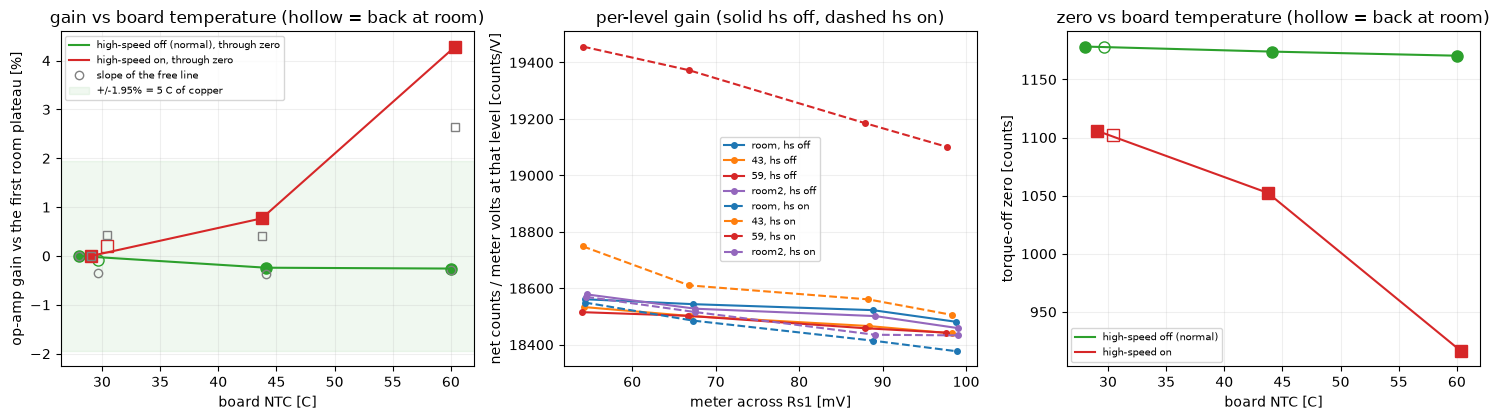

In [5]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4.3))
for hs, mk in (("off", "o"), ("on", "s")):
    g = G[G.hs == hs]
    for pl, x in g.groupby("plateau", observed=True):
        face = "none" if pl == "room2" else None
        axs[0].plot(x["board C"], x["G0 %"], mk, color="tab:green" if hs == "off" else "tab:red",
                    mfc=face, ms=8)
        axs[0].plot(x["board C"], x["slope %"], mk, color="grey", mfc="none", ms=6)
        axs[2].plot(x["board C"], x["zero"], mk, color="tab:green" if hs == "off" else "tab:red",
                    mfc=face, ms=8)
    first = g[g.plateau != "room2"]
    axs[0].plot(first["board C"], first["G0 %"], "-", color="tab:green" if hs == "off" else "tab:red",
                label=MODES[hs] + ", through zero")
    axs[2].plot(first["board C"], first["zero"], "-", color="tab:green" if hs == "off" else "tab:red",
                label=MODES[hs])
axs[0].plot([], [], "o", color="grey", mfc="none", label="slope of the free line")
band = THERM_BUDGET_C * ALPHA_CU * 100
axs[0].axhspan(-band, band, color="tab:green", alpha=0.07, label=f"+/-{band:.2f}% = {THERM_BUDGET_C:.0f} C of copper")
axs[0].set_xlabel("board NTC [C]")
axs[0].set_ylabel("op-amp gain vs the first room plateau [%]")
axs[0].set_title("gain vs board temperature (hollow = back at room)")
axs[2].set_xlabel("board NTC [C]")
axs[2].set_ylabel("torque-off zero [counts]")
axs[2].set_title("zero vs board temperature (hollow = back at room)")
for hs, ls in (("off", "-"), ("on", "--")):
    for _, x in G[G.hs == hs].iterrows():
        axs[1].plot(x["v_mv"], list(x["lvl"].values()), ls + "o", ms=4, color=COL[x["plateau"]],
                    label=f"{x['plateau']}, hs {hs}")
axs[1].set_xlabel("meter across Rs1 [mV]")
axs[1].set_ylabel("net counts / meter volts at that level [counts/V]")
axs[1].set_title("per-level gain (solid hs off, dashed hs on)")
for ax in axs:
    ax.grid(alpha=0.2)
    ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

**What you are looking at.** Left, the gain against board temperature in each mode, through zero
(filled) and as a slope (grey), with the 5 C thermometer budget shaded. Hollow markers are the
return to room. Middle, the gain at each of the four levels, one line per plateau and mode. Right,
the torque-off zero.

Normal mode sits flat inside the budget at every plateau. High-speed mode leaves it between 43 and
59 C, and its per-level lines fan out as the board warms, which is the growing offset.

## 3. R of the grid

The same grid was read for R in seven ways per plateau. The first one, `grid`, divides the chip's
vA - vB by the meter's current, so it has no op-amp in it. It says what the load and the terminal
chain did. Every other route uses the chip's current at the nominal counts per amp:

- `DC`, the same DC levels through the chip's current
- `lad40`, the ladder's 40% rung
- `late drv` and `late diff`, the bursts' late-window R from one tap or both taps (the
  `c0an.py` estimator, now `oscnb.opasweep.burst_levels`)
- `wave drv` and `wave diff`, what `osc ident`'s waveform fit printed

The second table is each route against the first room plateau of its mode, then each route
divided by `grid`, which leaves what the op-amp and the route itself did.

In [6]:
# R of the grid at each plateau, read six ways. Every route but the first divides the chip's
# terminal volts by a current that went through the op-amp at its nominal counts/A.
#   grid    chip vA-vB over the METER's current, DC levels: no op-amp in it at all
#   DC      chip vA-vB over the chip's current, the same DC levels
#   lad40   the duty ladder's 40% rung
#   late    burst late-window R: one tap ("drv") or the tap difference ("diff"), median of 120
#   wave    osc ident's waveform fit, mean of 5 runs per kind
rows = []
for (pl, hs), p in P.items():
    d = p.dc()
    lad = p.ladder()
    caps = p.bursts()
    caps = caps[caps.phase_ok]
    runs = p.runs()
    rows.append({"hs": hs, "plateau": pl, "board C": runs.board_c.mean(),
                 "grid": (d.v_ab / d.i_meter).mean(),
                 "grid 4.5 -> 8 V %": ((d.v_ab / d.i_meter).iloc[-1] / (d.v_ab / d.i_meter).iloc[0] - 1) * 100,
                 "DC": (d.v_ab / (d.i_net_mean * board.a_per_count)).mean(),
                 "lad40": lad[lad.duty == 40].r.iloc[0],
                 "late drv": caps[caps.kind == "staticwide"].r_drv.median(),
                 "late diff": caps[caps.kind == "staticwidediff"].r_diff.median(),
                 "wave drv": runs[runs.kind == "staticwide"].wave_r_ohm.mean(),
                 "wave diff": runs[runs.kind == "staticwidediff"].wave_r_ohm.mean(),
                 "dropped caps": int((~p.bursts().phase_ok).sum())})
R = pd.DataFrame(rows)
R["plateau"] = pd.Categorical(R.plateau, PLATS, ordered=True)
R = R.sort_values(["hs", "plateau"]).reset_index(drop=True)
ROUTES = ["grid", "DC", "lad40", "late drv", "late diff", "wave drv", "wave diff"]
RD = R[["hs", "plateau", "board C"]].copy()
for c in ROUTES:
    RD[c] = R.groupby("hs")[c].transform(lambda s: (s / s.iloc[0] - 1) * 100)
# What is left once the grid's own move is divided out: the chip's current against the meter's.
for c in ROUTES[1:]:
    RD[c + " / grid"] = ((R[c] / R["grid"]) / (R[c] / R["grid"]).groupby(R.hs).transform("first") - 1) * 100
print("R in ohm:")
display(R.set_index(["hs", "plateau"]).round(4))
print("% against the first room plateau of the same mode:")
display(RD.set_index(["hs", "plateau"]).round(2))

R in ohm:


board C    grid  grid 4.5 -> 8 V %      DC   lad40  late drv  \
hs  plateau                                                                 
off room     29.3843  4.1490             0.2257  4.1372  4.1884    4.4147   
    43       44.4296  4.1631             0.1493  4.1605  4.1863    4.4322   
    59       60.8654  4.1776             0.1429  4.1763  4.1988    4.4548   
    room2    30.8258  4.1334             0.2902  4.1240  4.1725    4.4035   
on  room     29.8171  4.1511             0.0519  4.1550  4.1977    4.4237   
    43       44.5145  4.1711            -0.1059  4.1415  4.1740    4.4193   
    59       60.9294  4.1744             0.0675  4.0004  4.0341    4.2896   
    room2    30.6524  4.1395             0.1145  4.1364  4.1781    4.4077   

             late diff  wave drv  wave diff  dropped caps  
hs  plateau                                                
off room        4.2005    4.1930     4.1980             0  
    43          4.2109    4.2172     4.2014             0  
    59          4.2243    4.2562     4.2046             0  
    room2       4.1891    4.1840     4.1700             0  
on  room        4.2137    4.2070     4.1978             1  
    43          4.2020    4.2074     4.1932             2  
    59          4.0717    4.0892     4.0536             0  
    room2       4.1941    4.1916     4.1714             0

% against the first room plateau of the same mode:


board C  grid    DC  lad40  late drv  late diff  wave drv  \
hs  plateau                                                              
off room       29.38  0.00  0.00   0.00      0.00       0.00      0.00   
    43         44.43  0.34  0.56  -0.05      0.40       0.25      0.58   
    59         60.87  0.69  0.95   0.25      0.91       0.57      1.51   
    room2      30.83 -0.38 -0.32  -0.38     -0.25      -0.27     -0.21   
on  room       29.82  0.00  0.00   0.00      0.00       0.00      0.00   
    43         44.51  0.48 -0.33  -0.57     -0.10      -0.28      0.01   
    59         60.93  0.56 -3.72  -3.90     -3.03      -3.37     -2.80   
    room2      30.65 -0.28 -0.45  -0.47     -0.36      -0.46     -0.37   

             wave diff  DC / grid  lad40 / grid  late drv / grid  \
hs  plateau                                                        
off room          0.00       0.00          0.00             0.00   
    43            0.08       0.23         -0.39             0.06   
    59            0.16       0.26         -0.44             0.22   
    room2        -0.67       0.06         -0.01             0.12   
on  room          0.00       0.00          0.00             0.00   
    43           -0.11      -0.80         -1.04            -0.58   
    59           -3.44      -4.26         -4.43            -3.57   
    room2        -0.63      -0.17         -0.19            -0.09   

             late diff / grid  wave drv / grid  wave diff / grid  
hs  plateau                                                       
off room                 0.00             0.00              0.00  
    43                  -0.09             0.24             -0.26  
    59                  -0.12             0.81             -0.53  
    room2                0.10             0.16             -0.29  
on  room                 0.00             0.00              0.00  
    43                  -0.76            -0.47             -0.59  
    59                  -3.91            -3.34             -3.97  
    room2               -0.19            -0.09             -0.35

**What you are looking at.** R in ohm, then R against room, then R against room with the grid's own
move divided out. The plot below shows the second table.

**The grid moved.** In normal mode the op-amp-free route reads +0.34% at 43 C, +0.69% at 59 C and
-0.38% back at room. In high-speed mode, captured minutes apart, it reads +0.48%, +0.56% and -0.28%.
The two modes agree, so this term belongs to the load or the terminal chain and the order things
ran in, not to the op-amp. The grid sits outside the dryer, but its resistors run past their rating
during every DC set. A grid that warms through the sequence fits it. So does the terminal dividers
drifting with the board, though back at room the board is 30 C and the grid reads 0.4% under
where it started, which a board-temperature drift would not do. The meter went on J4 only at room,
so this data cannot settle it (Open).

**With the grid divided out, normal mode is quiet.** `DC / grid` is +0.23% and +0.26%, the gain
change of section 2 seen from the R side. The both-taps routes stay within 0.6% at every plateau
(`late diff` -0.09%, -0.12%, `wave diff` -0.26%, -0.53%). The one-tap routes run higher (`wave drv`
+0.81% at 59 C), because one tap reads the low-side drop of the bridge as part of R, and that drop
grows with the board. The earlier normal-mode run's +1.5% one tap and +1.1% both taps at 59 C were
mostly the grid and the one-tap route.

**High-speed mode** leaves -3.3% to -4.4% at 59 C once the grid is out, the gain change of section 2
again.

There is one route that does not agree. The ladder's 40% rung reads -0.39% and -0.44% against the
grid where the DC levels read +0.23% and +0.26%. That is a 0.7% gap between two chip routes at one
plateau. It is listed under Open.

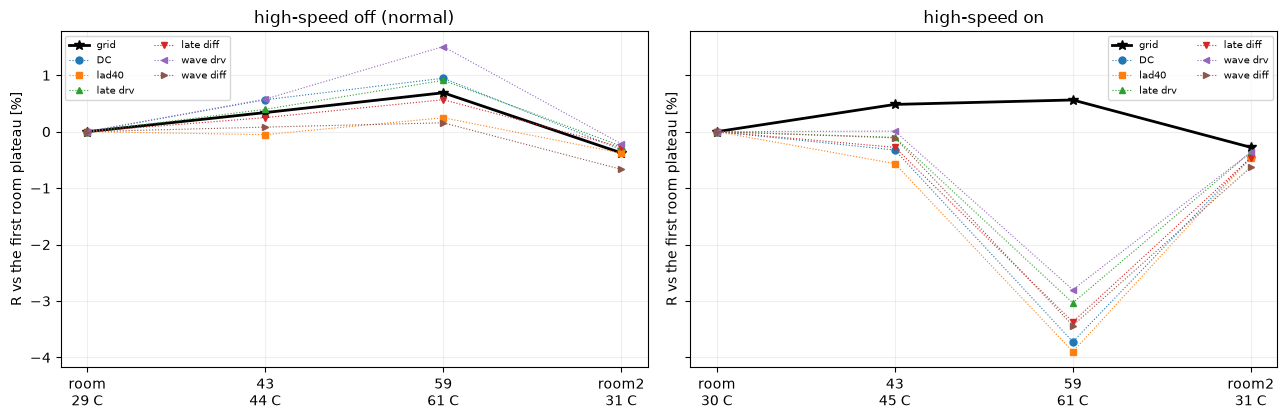

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(13, 4.3), sharey=True)
for ax, hs in zip(axs, ("off", "on")):
    g = RD[RD.hs == hs]
    x = np.arange(len(g))
    for c, mk in zip(ROUTES, ("k*", "o", "s", "^", "v", "<", ">")):
        ax.plot(x, g[c], mk + ("-" if c == "grid" else ":"), ms=7 if c == "grid" else 5,
                lw=2 if c == "grid" else 0.8, label=c)
    ax.set_xticks(x, [f"{pl}\n{t:.0f} C" for pl, t in zip(g.plateau, g["board C"])])
    ax.set_title(MODES[hs])
    ax.set_ylabel("R vs the first room plateau [%]")
    ax.grid(alpha=0.2)
    ax.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

**What you are looking at.** Each route against its mode's first room plateau. The black line is
the op-amp-free grid route. In normal mode every route follows it to within about 0.8%. In
high-speed mode they all fall away from it at 59 C together.

## 4. The lowest duty

How short can the drive window be before R from the taps goes wrong? The ladder answers it per
plateau and mode. A rung counts when the firmware calls its current window valid and its R sits
within 1% (or 3%) of the plateau's 30-40% rungs, and every rung above it does too.

hs           off   on     off      on   off    on
plateau     room room  43  43  59  59 room2 room2
min duty 1%   15   15  15  15  15  15    15    15
min duty 3%   10   10  10  10  10  10    10    10

tap B (the low side, forward drive) by rung, counts:


hs         off                          on                     
plateau     43     59   room  room2     43     59   room  room2
duty                                                           
3        607.7  608.9  606.9  607.3  608.1  608.6  606.9  607.5
4        609.4  610.0  608.6  608.9  609.7  610.0  608.5  608.8
5        610.8  611.2  610.3  610.4  611.0  611.4  610.2  610.3
6        612.7  613.4  612.0  612.2  613.0  613.4  612.3  612.4
8        615.9  616.7  615.2  615.4  616.2  616.8  615.5  615.7
10       654.4  658.5  651.1  651.7  654.5  658.6  651.4  651.8
15       699.4  704.6  695.4  696.1  699.6  704.8  695.8  696.4
20       704.3  708.6  699.6  700.3  704.6  708.8  700.0  700.6
30       712.3  716.3  708.8  709.5  712.5  716.5  709.2  709.9
40       720.7  724.7  716.5  717.2  721.0  724.9  717.0  717.6

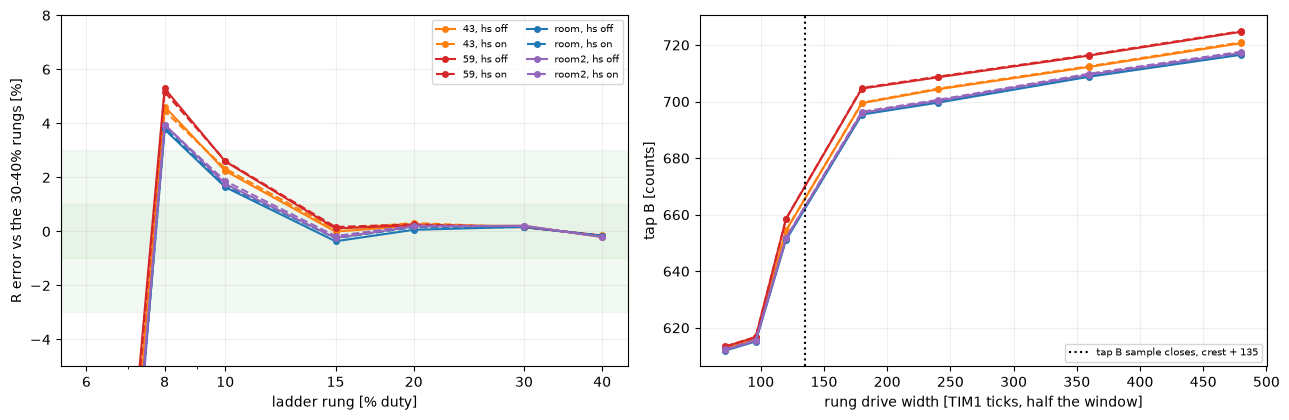

In [8]:
# The ladder, rung by rung: R from the taps at each duty against the same plateau's 30-40%
# rungs, and where each rung's error first stays inside 1% and 3%.
rows, mins = [], []
for (pl, hs), p in P.items():
    lad = p.ladder()
    ref = lad[lad.duty.isin((30, 40))].r.mean()
    lad["err %"] = (lad.r / ref - 1) * 100
    lad["plateau"], lad["hs"] = pl, hs
    rows.append(lad)
    m = {"hs": hs, "plateau": pl}
    for tol in (1.0, 3.0):
        bad = lad[~(lad.valid & (lad["err %"].abs() <= tol))]
        m[f"min duty {tol:.0f}%"] = lad[lad.duty > bad.duty.max()].duty.min()
    mins.append(m)
LAD = pd.concat(rows, ignore_index=True)
display(pd.DataFrame(mins).set_index(["hs", "plateau"]).T)
print("tap B (the low side, forward drive) by rung, counts:")
display(LAD.pivot_table(index="duty", columns=["hs", "plateau"], values="vb").round(1))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.3))
for (pl, hs), g in LAD.groupby(["plateau", "hs"]):
    g = g[g.valid]
    a1.plot(g.duty, g["err %"], ("-" if hs == "off" else "--") + "o", ms=4, color=COL[pl], label=f"{pl}, hs {hs}")
    a2.plot(g.ticks, g.vb, ("-" if hs == "off" else "--") + "o", ms=4, color=COL[pl])
for tol in (1, 3):
    a1.axhspan(-tol, tol, color="tab:green", alpha=0.06)
a1.set_xscale("log")
a1.set_xticks([6, 8, 10, 15, 20, 30, 40], ["6", "8", "10", "15", "20", "30", "40"])
a1.set_xlabel("ladder rung [% duty]")
a1.set_ylabel("R error vs the 30-40% rungs [%]")
a1.set_ylim(-5, 8)
a1.legend(fontsize=7, ncol=2)
B_CLOSE = ow.sample_close_ticks(ow.SCAN.index("tap B"))
a2.axvline(B_CLOSE, color="k", ls=":", label=f"tap B sample closes, crest + {B_CLOSE:.0f}")
a2.set_xlabel("rung drive width [TIM1 ticks, half the window]")
a2.set_ylabel("tap B [counts]")
a2.legend(fontsize=7)
for ax in (a1, a2):
    ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

**What you are looking at.** The table is the lowest duty within 1% and 3%, per plateau and mode.
Then tap B's reading at each rung. On the left, every rung's R error. On the right, tap B against the
rung's drive width in TIM1 ticks, with the moment tap B's TEL sample closes.

**Every plateau in both modes gives 15% for 1% and 10% for 3%.** The op-amp mode changes nothing,
and neither does temperature. The 8% rung reads +3.8% to +5.3% high and the 10% rung +1.6% to
+2.6%.

Tap B says why. On a forward drive tap B is the low side. At the 6% and 8% rungs it reads 612 to
617 counts, the same as the bridge's brake level. At 15% and up it reads its ON level, 695 to 705.
The 10% rung is half way. So below 10% the TEL scan reads tap B after the drive window has
already closed, and vA - vB comes out too big by the whole low-side drop. At 6% tap A's own
sample, the second slot at 83 ticks, lands on its edge as well, and vA - vB collapses to -30%.

The scan timing gives the moment. The ADC runs at 24 MHz against 48 MHz TIM1 ticks, every slot
takes 26 ADC clocks, the aperture is 13.5 clocks, and the trigger has 2 clocks of delay. Tap B is
the third slot, so its sample closes $(2 + 13.5 + 2 \cdot 26) \cdot 2 = 135$ ticks after the crest.
A drive window of $h$ ticks ends about $h$ ticks after the crest.

The 8% error also grows with the board, +3.8% at room to +5.3% at 59 C. Tap B's ON level climbs
with the board (695 to 705 counts at 15%) while its brake level stays put, so the share of the
low-side drop that goes missing grows. That fits the bridge's low-side resistance rising with
temperature, but this data does not measure it directly.

To see the edge itself, the bursts fold back onto the PWM period.

window end past the commanded half width, ticks (50% = half way down, 10% = first 10% of the drop):


hs          off                      on                  
plateau    room    43    59 room2  room    43    59 room2
tap ticks                                                
ta  120    14.6  13.2  14.8  13.4  14.4  13.4  14.8  13.4
    180    14.6  13.5  14.9  13.5  14.7  13.9  14.9  13.2
    300    14.6  13.3  13.5  13.3  14.8  14.8  14.9  14.5
    456    14.7  13.5  14.9  14.7  14.0  14.1  13.5  14.7
tb  120    14.8  15.0  16.0  15.2  14.9  15.3  15.4  14.9
    180    17.8  15.9  16.1  18.2  15.9  18.2  15.7  17.0
    300    16.2  14.7  16.4  16.2  16.1  15.6  17.5  19.3
    456    17.6  15.6  17.8  17.5  15.4  17.0  15.6  17.6

hs        off                      on                  
plateau  room    43    59 room2  room    43    59 room2
ticks                                                  
120      10.1  10.2  10.3  10.3  10.3  10.3  10.4  10.3
180       6.8  10.5  10.0  10.9   8.7  11.2  10.1  10.8
300      10.5  10.3  10.2  10.3  10.5  10.2  10.3  11.0
456      11.4  10.4   9.2  11.1  10.1  10.7  10.2  10.7

tap B: half way down 16.3 ticks past the half width (sd 1.2, all duties, plateaus and modes); 10% down at 10.3 (sd 0.8)
tap A, half way down past the half width, mean over the four duties:
plateau  room    43    59  room2
hs                              
off      14.6  13.4  14.5   13.7
on       14.5  14.1  14.5   14.0
tap B sampled at crest + 135 sits half way down the falling edge at 9.9% duty, and ahead of the first 10% of the drop from 10.4%


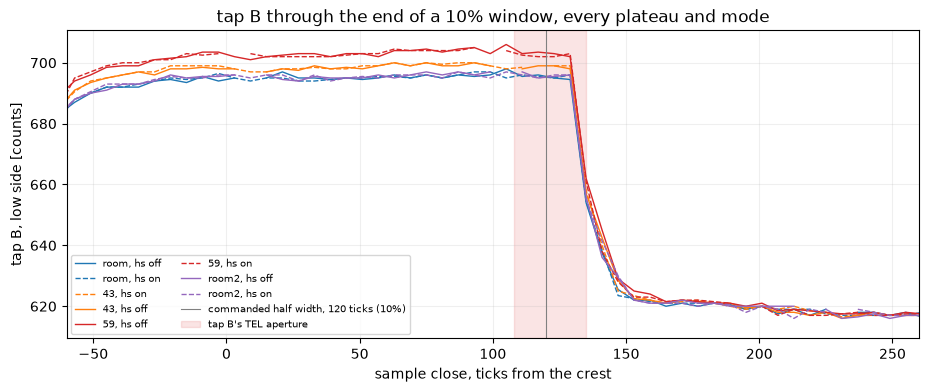

In [9]:
# Fold the bursts that drive forward and read both taps: tap A is the high side, tap B the low
# side. Each sample sits at a known time from the crest, so 120 captures per duty draw the
# taps through the whole PWM period. Find where each tap crosses half way down at the end of the
# window, and where tap B is 90% of the way, against the commanded half width.
def profile(t, y, lo, hi, w=4):
    edges = np.arange(lo, hi + w, w)
    i = np.digitize(t, edges) - 1
    return edges[:-1] + w / 2, np.array([np.median(y[i == k]) if np.any(i == k) else np.nan
                                         for k in range(len(edges) - 1)])


def down_crossing(x, y, level, lo):
    ok = np.isfinite(y)
    x, y = x[ok], y[ok]
    for k in range(1, len(x)):
        if x[k] > lo and y[k - 1] > level >= y[k]:
            return x[k - 1] + (level - y[k - 1]) / (y[k] - y[k - 1]) * (x[k] - x[k - 1])
    return np.nan


rows = []
for (pl, hs), p in P.items():
    got = {}
    for x, f in p.burst_files():
        df = pd.read_csv(f)
        m = {k: int(df[k].iloc[0]) for k in df.columns[2:]}
        if m["step_q15"] <= 0:
            continue
        ticks = round(m["step_q15"] * board.pwm_half_ticks / 32768)
        for s in ("ta", "tb") if x.kind == "staticwidediff" else ("ta",):
            t, y, _ = ow.fold(df, board, s)
            got.setdefault((ticks, s), []).append((t, y))
    for (ticks, s), parts in got.items():
        t = np.concatenate([a for a, _ in parts])
        y = np.concatenate([b for _, b in parts])
        x, prof = profile(t, y, -ticks - 300, ticks + 500, w=6)
        off = np.nanmedian(prof[np.abs(x) >= ticks + 200])
        on = np.nanmedian(prof[(x > 0) & (x < ticks - 58)])
        rows.append({"hs": hs, "plateau": pl, "ticks": ticks, "tap": s,
                     "fall 50%": down_crossing(x, prof, off + 0.5 * (on - off), 0) - ticks,
                     "fall 10%": down_crossing(x, prof, off + 0.9 * (on - off), 0) - ticks,
                     "on": on, "off": off,
                     "at B close": np.interp(B_CLOSE, x, prof), "x": x, "prof": prof})
FOLD = pd.DataFrame(rows)
FOLD["plateau"] = pd.Categorical(FOLD.plateau, PLATS, ordered=True)
print("window end past the commanded half width, ticks (50% = half way down, 10% = first 10% of the drop):")
display(FOLD.pivot_table(index=["tap", "ticks"], columns=["hs", "plateau"], values="fall 50%", observed=True).round(1))
display(FOLD[FOLD.tap == "tb"].pivot_table(index="ticks", columns=["hs", "plateau"], values="fall 10%",
                                            observed=True).round(1))
e50 = FOLD[FOLD.tap == "tb"]["fall 50%"]
e10 = FOLD[FOLD.tap == "tb"]["fall 10%"]
print(f"tap B: half way down {e50.mean():.1f} ticks past the half width (sd {e50.std():.1f}, all duties, "
      f"plateaus and modes); 10% down at {e10.mean():.1f} (sd {e10.std():.1f})")
ea = FOLD[FOLD.tap == "ta"].groupby(["hs", "plateau"], observed=True)["fall 50%"].mean()
print("tap A, half way down past the half width, mean over the four duties:")
print(ea.unstack("plateau").round(1).to_string())
DUTY_EDGE = (B_CLOSE - e50.mean()) / board.pwm_half_ticks * 100
DUTY_CLEAN = (B_CLOSE - e10.mean()) / board.pwm_half_ticks * 100
print(f"tap B sampled at crest + {B_CLOSE:.0f} sits half way down the falling edge at {DUTY_EDGE:.1f}% duty, "
      f"and ahead of the first 10% of the drop from {DUTY_CLEAN:.1f}%")

fig, ax = plt.subplots(figsize=(11, 4))
for _, r in FOLD[(FOLD.tap == "tb") & (FOLD.ticks == 120)].iterrows():
    ax.plot(r.x, r.prof, "-" if r.hs == "off" else "--", color=COL[r.plateau], lw=1,
            label=f"{r.plateau}, hs {r.hs}")
ax.axvline(120, color="grey", lw=0.8, label="commanded half width, 120 ticks (10%)")
ax.axvspan(B_CLOSE - ow.APERTURE_CLK * ow.TICKS_PER_ADC_CLK, B_CLOSE, color="tab:red", alpha=0.12,
           label="tap B's TEL aperture")
ax.set_xlim(-60, 260)
ax.set_xlabel("sample close, ticks from the crest")
ax.set_ylabel("tap B, low side [counts]")
ax.set_title("tap B through the end of a 10% window, every plateau and mode")
ax.grid(alpha=0.2)
ax.legend(fontsize=7, ncol=2)
plt.show()

**What you are looking at.** The first table is where each tap is half way down at the end of the
window, in ticks past the commanded half width, per duty, plateau and mode. The second is where tap B
has dropped its first 10%. The plot is tap B through the end of a 10% window, all eight plateau and
mode runs on top of each other, with tap B's TEL aperture shaded.

Tap A's falling edge sits 13 to 15 ticks past the commanded width at every plateau, with no trend
with temperature. Tap B's is half way down 16.3 ticks past it (sd 1.2) and starts to drop 10.3
ticks past it (sd 0.8). All eight curves in the plot land on the same edge. **The edges do not move
with temperature.**

Putting it together, tap B's sample at 135 ticks is half way down the edge at 9.9% duty and clear
of it from about 10.4%. The ladder has no rung between 10% and 15%, which is why the 1% floor reads
15%. The firmware's terminal floor of 160 ticks (13.3%) already sits above the edge with some margin.

The root cause is the scan order, not the op-amp and not the temperature. A firmware change that
samples tap B before the crest, where even a short window is still on, is in progress. It is not
done, and nothing in this notebook tests it.

## 5. What this decides

**The op-amp runs in normal mode (high-speed off) on today's hardware.** Its gain moves 0.26% over
32 C of board, which is 0.66 C of thermometer error, about a seventh of the 5 C budget. Its zero
moves 8 counts and comes back. High-speed mode costs 11 C of error at 59 C, and it bends hard
between 43 and 59 C.

**No hardware rework for the current sense.** The plan going in had a gain-4 / 150 mOhm rework and
a pull-up test on the op-amp inputs to check whether their low common-mode voltage causes the drift.
With normal mode already inside the budget, neither is needed for the thermometer. The common-mode
test with two 1K6 pull-ups was dropped.

**The remaining low-duty limit is a firmware timing problem** (section 4), and it is the same in
both modes at every temperature.

What still has to happen before the thermometer can lean on this: the in-drive offset needs a cause,
the grid needs replacing with a load that does not move, and the MG90's own R against temperature
needs measuring with the servo in the dryer.

## Caveats

- **One board, one chip, one evening.** One plateau per temperature, four DC levels of about 5 s
  each. Another V006 could drift differently.
- **The board NTC is the board, not the op-amp die.** The die sits a few mm away, and the DC sets
  warm it for seconds at a time.
- **The shunt is not graded.** The meter reads the volts across Rs1, so the shunt's own tolerance
  and temperature coefficient are outside this test. In a servo the shunt warms with the board too,
  and its drift adds to the op-amp's.
- **The meter's absolute accuracy is not graded either.** Every gain figure here is a ratio on one
  meter range, which cancels its scale. The 14.92 amplifier gain does lean on it.
- **The gain through zero assumes the torque-off zero.** The firmware uses the same zero, so that is
  the number that matters for it, but it mixes the gain with the in-drive offset at a given current.
- **The grid is not a reference.** It moved 0.7% during the sweep, and section 3 divides it out with
  a route that leans on the terminal chain, checked against J4 at room only.
- **Three burst captures were dropped**, two in high-speed mode at 43 C and one at room, because the
  counter read at their start landed off the real PWM phase.

## Open

- **The in-drive offset (section 2).** About +10 counts in normal mode and 21 to 46 counts in
  high-speed mode, present while the bridge drives and absent from the torque-off zero. Candidates:
  (a) the op-amp's offset changing with its input common-mode voltage, which rises with the
  current, (b) a ground or reference shift that comes with the bridge being active. To separate
  them, read the chip against the meter at a few much smaller currents (a high-ohm load, or the supply at 1 to
  2 V). (a) predicts the line bends back toward the torque-off zero as the current falls. (b)
  predicts the intercept holds all the way down.
- **The zero rises 6 to 10 counts over each plateau's runs**, start to end, in both modes, even
  where the board NTC did not move (43 C normal mode, +0.02 C and +7 counts). Candidates: (a) heat
  near the op-amp from the DC sets and bursts that the board NTC does not see, (b) the op-amp's
  offset settling slowly after the high-current levels. Logging the zero every few seconds for 15
  minutes after a DC set separates them. (a) predicts it decays back with a thermal time constant,
  (b) predicts no tie to how much heat went in, so a DC set at half the current gives the same rise.
- **What moved the grid route (section 3).** +0.7% at 59 C and -0.4% back at room, in both modes.
  Candidates: (a) the grid's own temperature through the sequence, (b) the terminal dividers drifting
  with the board. The meter on J4 at a hot plateau separates them: (a) predicts chip vA - vB still
  agrees with the meter at J4, (b) predicts it does not. A low temperature coefficient wirewound load
  in place of the grid removes (a) outright.
- **The ladder's 40% rung against the DC levels (section 3)**, -0.4% against +0.25% with the grid
  divided out, at 43 and 59 C. Candidates: (a) the grid at a different temperature between the DC
  set and the ladder a minute later, (b) a PWM-only term (the settle gain, the low-side drop at
  40%). The wirewound load predicts the gap closes under (a) and stays under (b).
- **The slope's hysteresis in normal mode (section 2).** The slope reads -0.35% back at room against
  a standard error of 0.21%. A return-to-room plateau with more DC levels (eight instead of four)
  would cut the error enough to say whether it is real.